
📂 Loading dataset...

📊 First 2 rows of dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70          0.0             1.9      0.076   
1            7.8              0.88          0.0             2.6      0.098   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   

   alcohol  quality  
0      9.4        5  
1      9.8        5  

🔹 Checking for missing values...
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

📊 Distribution of Wine Quality:
quality
5    681
6    638
7    199

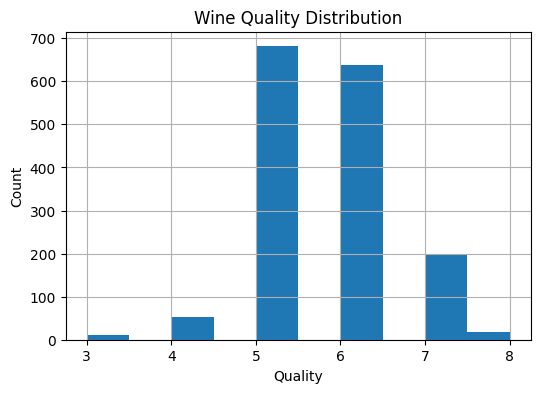

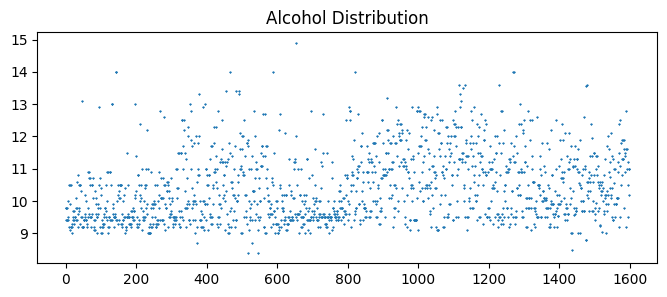

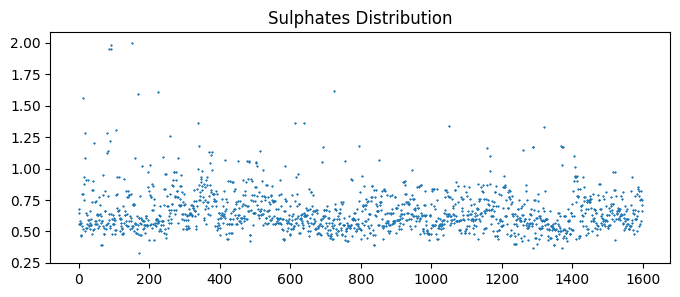


✅ Features (X) and Target (y) prepared
X shape: (1599, 11)
y distribution:
 good
0    1382
1     217
Name: count, dtype: int64

✅ Train/Test Split completed
Train size: 1279
Test size: 320

🔹 Creating and training models...

📊 Logistic Regression Results
Accuracy:   0.89375
Recall:     0.37209302325581395
Precision:  0.6956521739130435
F1 Score:   0.48484848484848486

📊 Linear SVM Results
Accuracy:   0.865625
Recall:     0.0
Precision:  0.0
F1 Score:   0.0

📊 Decision Tree Results
Accuracy:   0.903125
Recall:     0.6976744186046512
Precision:  0.625
F1 Score:   0.6593406593406593

📊 Random Forest Results
Accuracy:   0.946875
Recall:     0.627906976744186
Precision:  0.9642857142857143
F1 Score:   0.7605633802816901


c:\Users\User\miniconda3\envs\csitB\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [3]:
# ================================================================
# 📌 1. Data Loading
# ================================================================
import pandas as pd

print("\n📂 Loading dataset...")
df = pd.read_csv("./data/winequality-red.csv")  # dataset path

print("\n📊 First 2 rows of dataset:")
print(df.head(2))


# ================================================================
# 📌 2. Data Cleaning
# ================================================================
print("\n🔹 Checking for missing values...")
print(df.isnull().sum())

# Convert wine quality into binary classification (good / bad)
df["good"] = (df["quality"] >= 7).astype(int)


# ================================================================
# 📌 3. Exploratory Data Analysis (EDA)
# ================================================================
import matplotlib.pyplot as plt

print("\n📊 Distribution of Wine Quality:")
print(df["quality"].value_counts())

plt.figure(figsize=(6,4))
df["quality"].hist(bins=10)
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Wine Quality Distribution")
plt.show()

# Example feature visualization
plt.figure(figsize=(8,3))
plt.plot(df.index, df["alcohol"], '*', ms=1)
plt.title("Alcohol Distribution")
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df.index, df["sulphates"], '*', ms=1)
plt.title("Sulphates Distribution")
plt.show()


# ================================================================
# 📌 4. Preprocessing
# ================================================================
from sklearn.preprocessing import StandardScaler

X = df.drop(["quality", "good"], axis=1)
y = df["good"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ================================================================
# 📌 5. Independent & Dependent Variables
# ================================================================
print("\n✅ Features (X) and Target (y) prepared")
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())


# ================================================================
# 📌 6. Train/Test Split
# ================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Train/Test Split completed")
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


# ================================================================
# 📌 7. Model Creation & Training
# ================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("\n🔹 Creating and training models...")

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


# ================================================================
# 📌 8. Prediction
# ================================================================
y_pred_log = log_reg.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)


# ================================================================
# 📌 9. Performance Score Calculation
# ================================================================
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def evaluate_model(name, y_test, y_pred):
    print(f"\n📊 {name} Results")
    print("Accuracy:  ", accuracy_score(y_test, y_pred))
    print("Recall:    ", recall_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("F1 Score:  ", f1_score(y_test, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Linear SVM", y_test, y_pred_svm)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
